# Diabetes Classification & Clustering
## Multi-Class Prediction of Diabetes Status

**Classes:** N = Non-diabetic | Y = Diabetic | P = Predict-diabetic

**Author:** Aananda Giri  
**Date:** 2026-05-19

## 0. Imports and Configuration

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score,
                             ConfusionMatrixDisplay, silhouette_score,
                             adjusted_rand_score, normalized_mutual_info_score,
                             homogeneity_score, completeness_score, v_measure_score,
                             davies_bouldin_score, calinski_harabasz_score)

# XGBoost
from xgboost import XGBClassifier

# Imbalanced learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Clustering & Dimensionality Reduction
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plotting defaults
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.dpi': 100,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12
})

print('All imports successful.')

All imports successful.


## 1. Data Loading and Initial Inspection

In [2]:
# Load CSV — uses \\r line terminators (legacy Mac format)
df = pd.read_csv('Diabetes Dataset/Dataset of Diabetes .csv', lineterminator='\r')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(10)

Shape: (1001, 14)
Columns: ['ID', 'No_Pation', 'Gender', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI', 'CLASS']


,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975.0,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221.0,M,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975.0,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656.0,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223.0,M,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N
5,634,34224.0,F,45.0,2.3,24.0,4.0,2.9,1.0,1.0,1.5,0.4,21.0,N
6,721,34225.0,F,50.0,2.0,50.0,4.0,3.6,1.3,0.9,2.1,0.6,24.0,N
7,421,34227.0,M,48.0,4.7,47.0,4.0,2.9,0.8,0.9,1.6,0.4,24.0,N
8,670,34229.0,M,43.0,2.6,67.0,4.0,3.8,0.9,2.4,3.7,1.0,21.0,N
9,759,34230.0,F,32.0,3.6,28.0,4.0,3.8,2.0,2.4,3.8,1.0,24.0,N


In [3]:
# Data types and null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1001 non-null   str    
 1   No_Pation  1000 non-null   float64
 2   Gender     1000 non-null   str    
 3   AGE        1000 non-null   float64
 4   Urea       1000 non-null   float64
 5   Cr         1000 non-null   float64
 6   HbA1c      1000 non-null   float64
 7   Chol       1000 non-null   float64
 8   TG         1000 non-null   float64
 9   HDL        1000 non-null   float64
 10  LDL        1000 non-null   float64
 11  VLDL       1000 non-null   float64
 12  BMI        1000 non-null   float64
 13  CLASS      1000 non-null   str    
dtypes: float64(11), str(3)
memory usage: 109.6 KB


In [4]:
# Check for missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print('No missing values found.')
else:
    print('Missing values per column:')
    print(missing)
    print(f'\nDropping {df.isnull().any(axis=1).sum()} row(s) with missing values...')
    df = df.dropna()
    print(f'Shape after dropping NAs: {df.shape}')

Missing values per column:
No_Pation    1
Gender       1
AGE          1
Urea         1
Cr           1
HbA1c        1
Chol         1
TG           1
HDL          1
LDL          1
VLDL         1
BMI          1
CLASS        1
dtype: int64

Dropping 1 row(s) with missing values...
Shape after dropping NAs: (1000, 14)


In [5]:
# Drop identifier columns (ID and No_Pation are just row identifiers)
df = df.drop(columns=['ID', 'No_Pation'])
print(f'Shape after dropping IDs: {df.shape}')
df.head()

Shape after dropping IDs: (1000, 12)


,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,M,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,M,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [6]:
# Check for duplicates
dup_count = df.duplicated().sum()
print(f'Duplicate rows: {dup_count}')
if dup_count > 0:
    df = df.drop_duplicates()
    print(f'After dropping duplicates, shape: {df.shape}')

# Strip whitespace from categorical columns
df['Gender'] = df['Gender'].str.strip()
df['CLASS'] = df['CLASS'].str.strip()

# Verify CLASS values
print(f'\nCLASS distribution:')
print(df['CLASS'].value_counts())
print(f'\nUnique Gender values: {df["Gender"].unique()}')
print(f'Unique CLASS values: {df["CLASS"].unique()}')

Duplicate rows: 169
After dropping duplicates, shape: (831, 12)

CLASS distribution:
CLASS
Y    695
N     96
P     40
Name: count, dtype: int64

Unique Gender values: <StringArray>
['F', 'M', 'f']
Length: 3, dtype: str
Unique CLASS values: <StringArray>
['N', 'P', 'Y']
Length: 3, dtype: str


## 2. Exploratory Data Analysis — Univariate

### 2.1 Target Variable Distribution

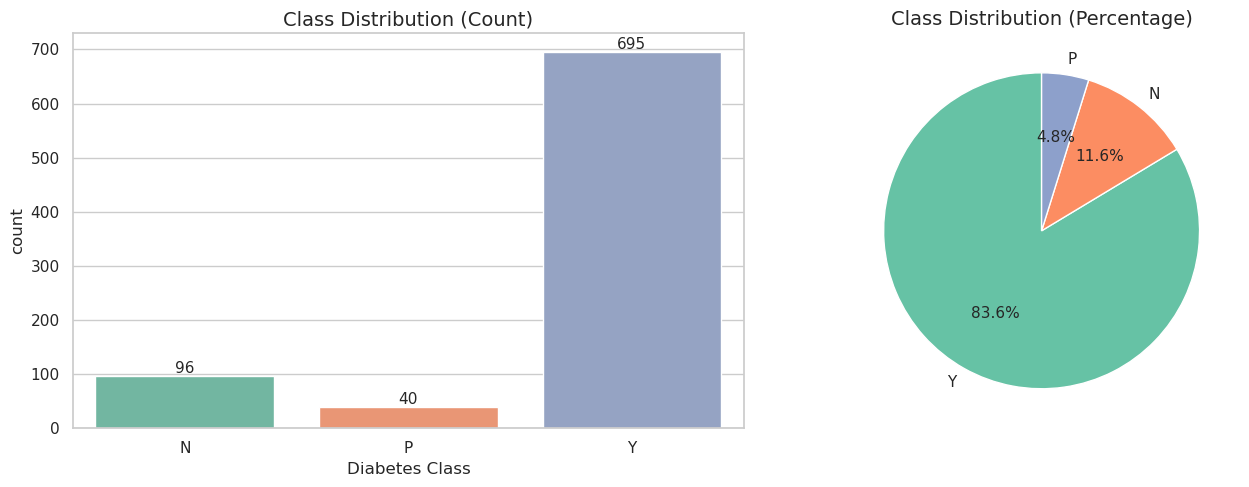

Class Distribution Summary:
       Count  Percentage
CLASS                   
Y        695       83.63
N         96       11.55
P         40        4.81

Imbalance ratio (largest/smallest): 17.4:1


In [7]:
# Class distribution
class_counts = df['CLASS'].value_counts()
class_pct = df['CLASS'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(data=df, x='CLASS', order=['N', 'P', 'Y'], palette='Set2', ax=axes[0])
axes[0].set_title('Class Distribution (Count)')
axes[0].set_xlabel('Diabetes Class')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Pie chart
axes[1].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', 3), startangle=90)
axes[1].set_title('Class Distribution (Percentage)')

plt.tight_layout()
plt.show()

# Summary stat table
summary = pd.DataFrame({'Count': class_counts, 'Percentage': class_pct.round(2)})
print('Class Distribution Summary:')
print(summary)
print(f'\nImbalance ratio (largest/smallest): {class_counts.max() / class_counts.min():.1f}:1')

### 2.2 Numeric Feature Summary Statistics

In [8]:
# Summary statistics for numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Numeric features ({len(numeric_cols)}): {numeric_cols}\n')
df[numeric_cols].describe().T

Numeric features (10): ['AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI']



,count,mean,std,min,25%,50%,75%,max
AGE,831.0,53.418773,8.870302,20.0,51.00,55.0,59.0,79.00
Urea,831.0,5.183566,3.070515,0.5,3.63,4.6,5.7,38.90
Cr,831.0,68.971119,59.393210,6.0,48.00,59.0,73.0,800.00
HbA1c,831.0,8.332202,2.607280,0.9,6.50,8.1,10.2,16.00
Chol,831.0,4.896053,1.326116,0.0,4.00,4.8,5.6,10.30
TG,831.0,2.395283,1.453699,0.3,1.50,2.0,3.0,13.80
HDL,831.0,1.211974,0.678072,0.2,0.90,1.1,1.3,9.90
LDL,831.0,2.591083,1.129763,0.3,1.70,2.5,3.3,9.90
VLDL,831.0,1.810710,3.571375,0.1,0.70,1.0,1.5,35.00
BMI,831.0,29.487918,5.006987,19.0,26.00,30.0,33.0,47.75


### 2.3 Feature Distributions — Histograms with KDE

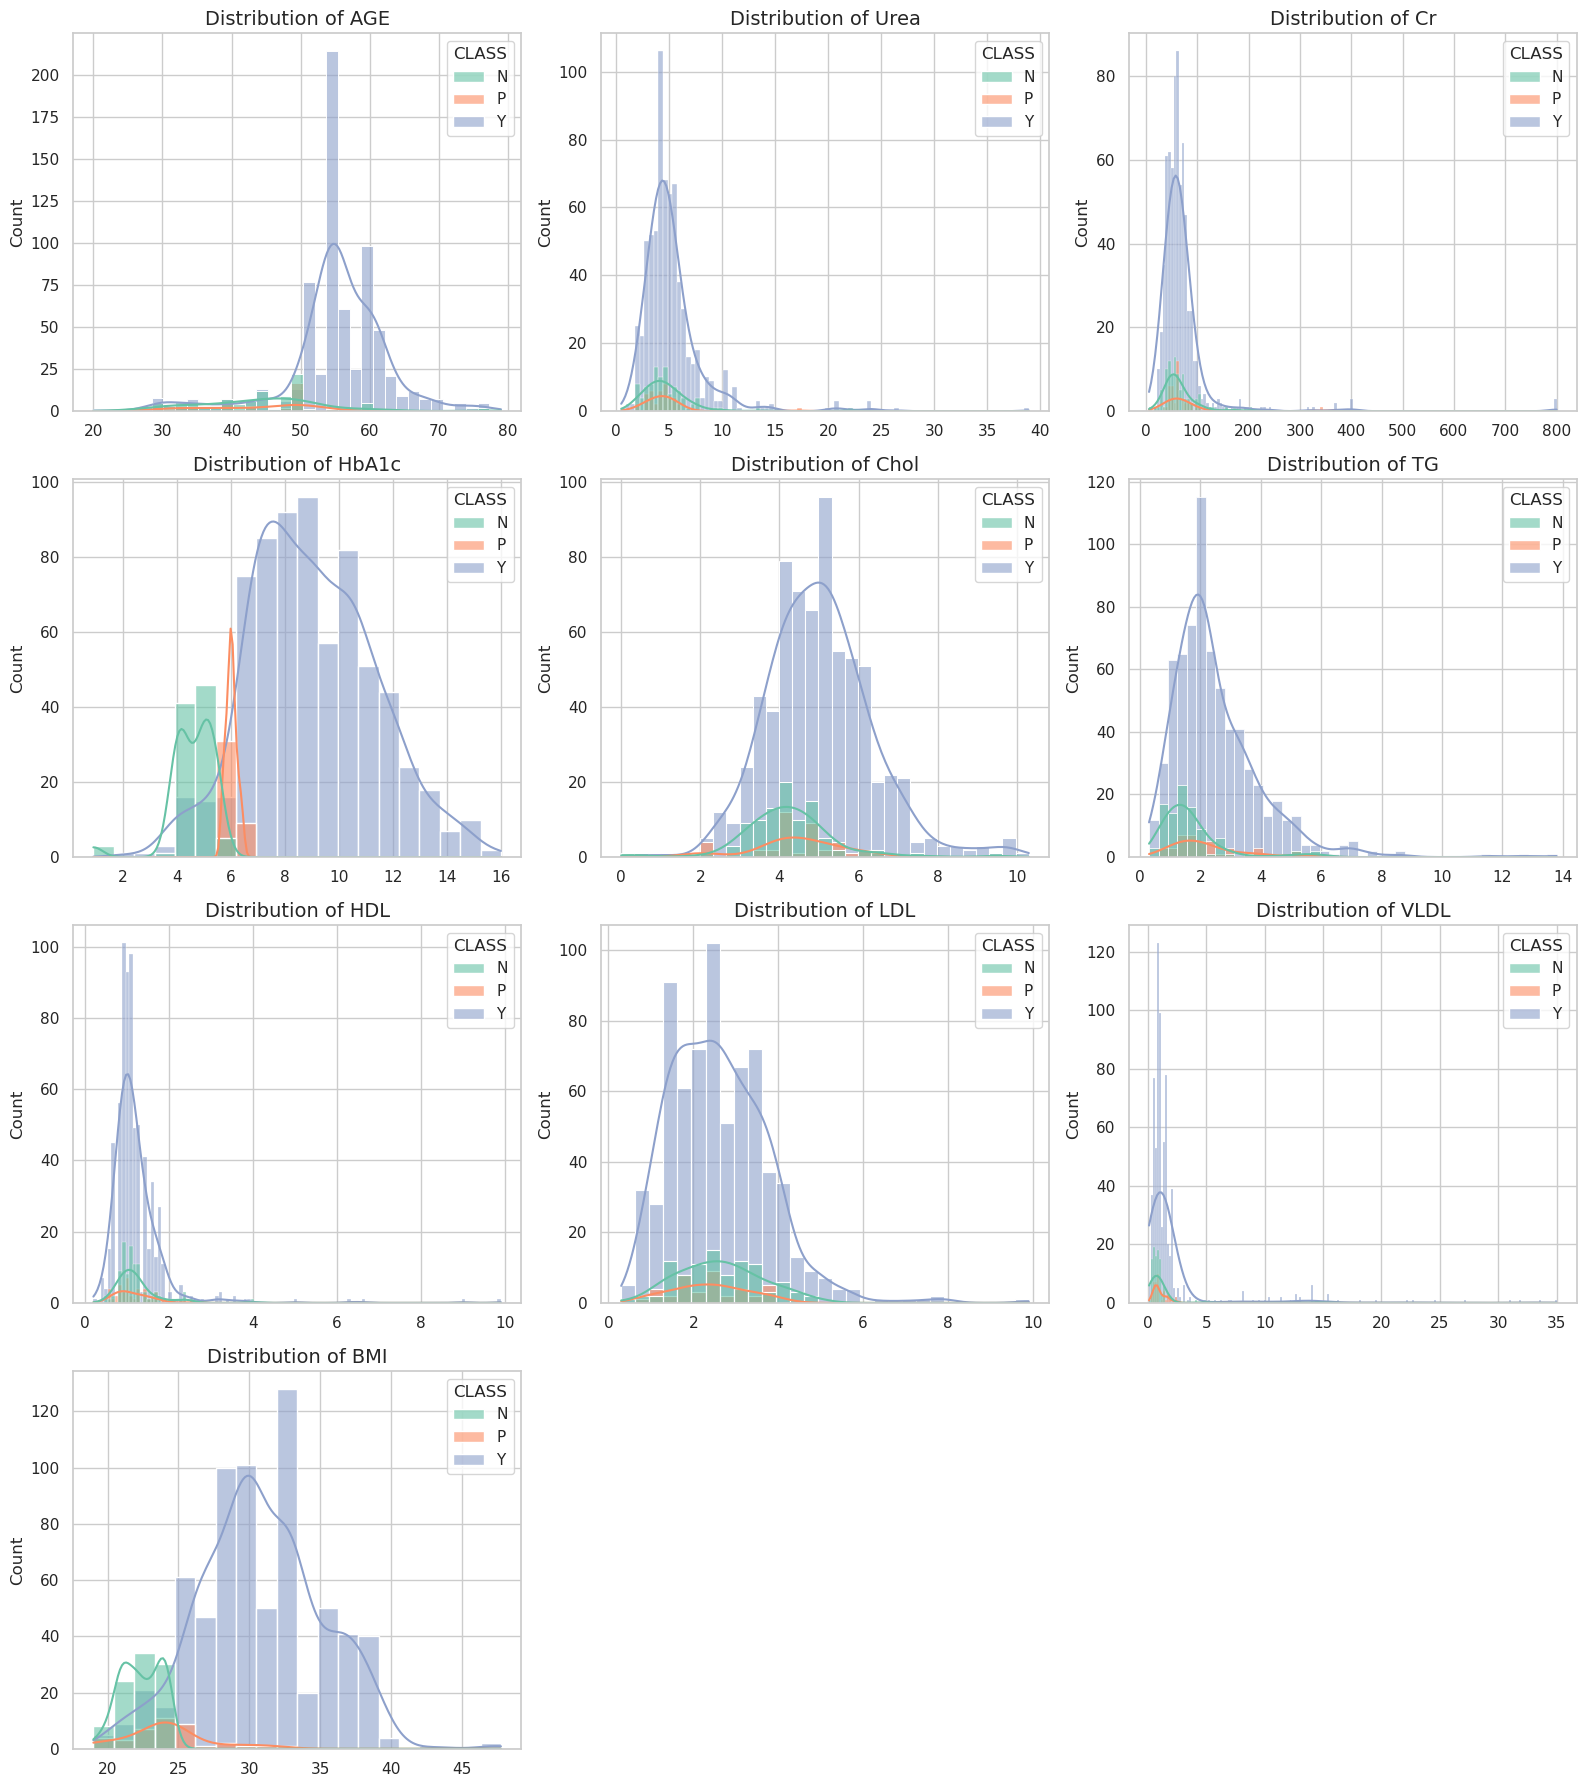

In [9]:
fig, axes = plt.subplots(4, 3, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, kde=True, hue='CLASS', palette='Set2', ax=axes[i], alpha=0.6)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')

# Hide any extra subplots
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### 2.4 Skewness Analysis

Skewness of numeric features:
  Cr        :  +8.169  (right-skewed)
  HDL       :  +6.302  (right-skewed)
  VLDL      :  +5.690  (right-skewed)
  Urea      :  +4.264  (right-skewed)
  TG        :  +2.303  (right-skewed)
  LDL       :  +1.005  (right-skewed)
  Chol      :  +0.579  (right-skewed)
  HbA1c     :  +0.189  (symmetric-skewed)
  BMI       :  +0.081  (symmetric-skewed)
  AGE       :  -0.814  (left-skewed)


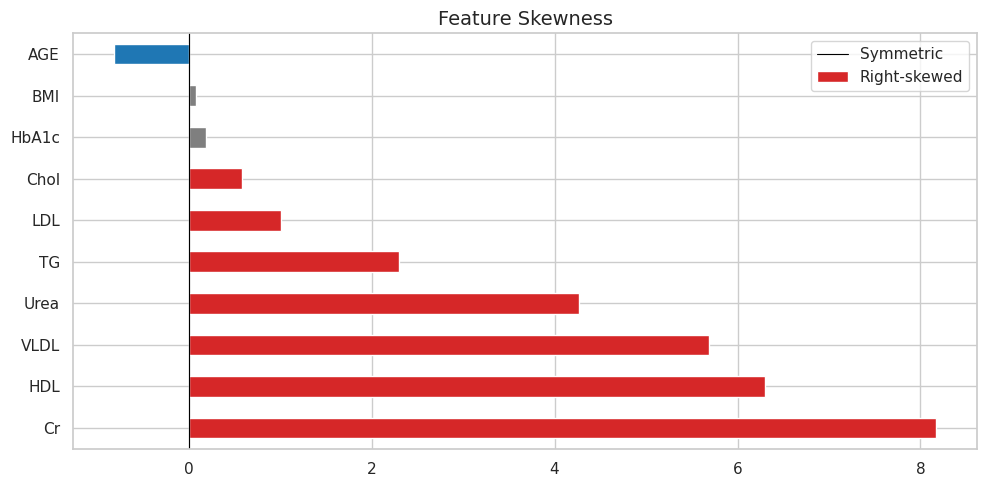

In [10]:
# Skewness per numeric feature
skew = df[numeric_cols].skew().sort_values(ascending=False)
print('Skewness of numeric features:')
for col, val in skew.items():
    direction = 'right' if val > 0.5 else ('left' if val < -0.5 else 'symmetric')
    print(f'  {col:10s}: {val:+7.3f}  ({direction}-skewed)')

# Bar plot
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d62728' if v > 0.5 else '#1f77b4' if v < -0.5 else '#7f7f7f' for v in skew.values]
skew.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Skewness')
ax.legend(['Symmetric', 'Right-skewed', 'Left-skewed'])
plt.tight_layout()
plt.show()

### 2.5 Gender Distribution

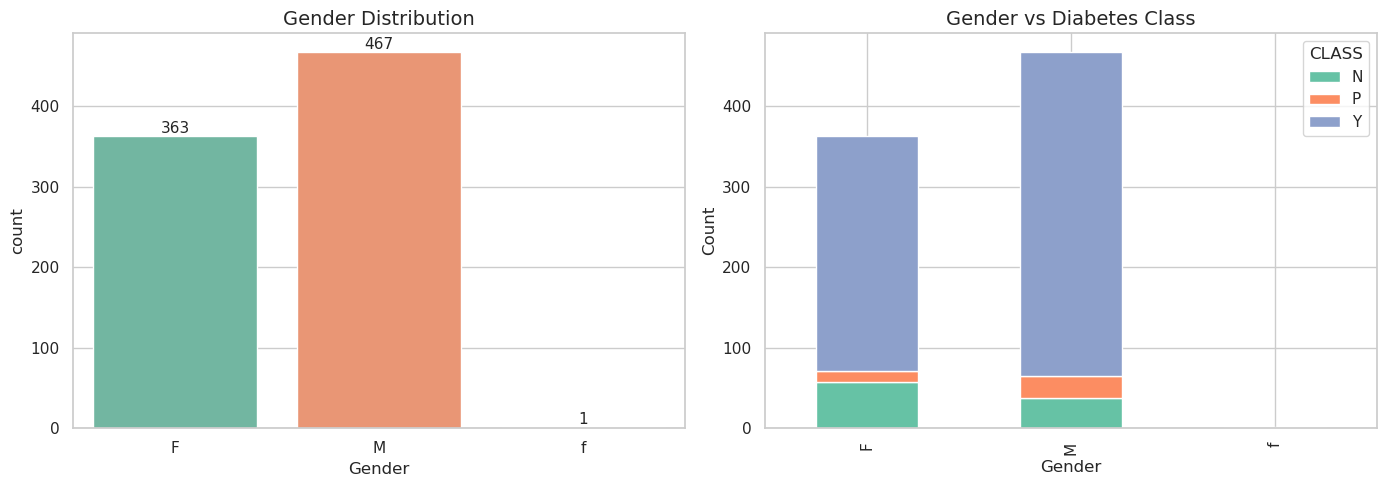

Gender x CLASS Crosstab:
CLASS    N   P    Y
Gender             
F       58  13  292
M       38  27  402
f        0   0    1

Gender proportions:
Gender
M    56.20
F    43.68
f     0.12
Name: proportion, dtype: float64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender count
sns.countplot(data=df, x='Gender', palette='Set2', ax=axes[0])
axes[0].set_title('Gender Distribution')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom')

# Gender vs CLASS
gender_class = pd.crosstab(df['Gender'], df['CLASS'])
gender_class.plot(kind='bar', stacked=True, ax=axes[1], color=sns.color_palette('Set2', 3))
axes[1].set_title('Gender vs Diabetes Class')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

print('Gender x CLASS Crosstab:')
print(gender_class)
print(f'\nGender proportions:')
print(df['Gender'].value_counts(normalize=True).mul(100).round(2))

## 3. Exploratory Data Analysis — Bivariate

### 3.1 Feature vs Class — Boxplots

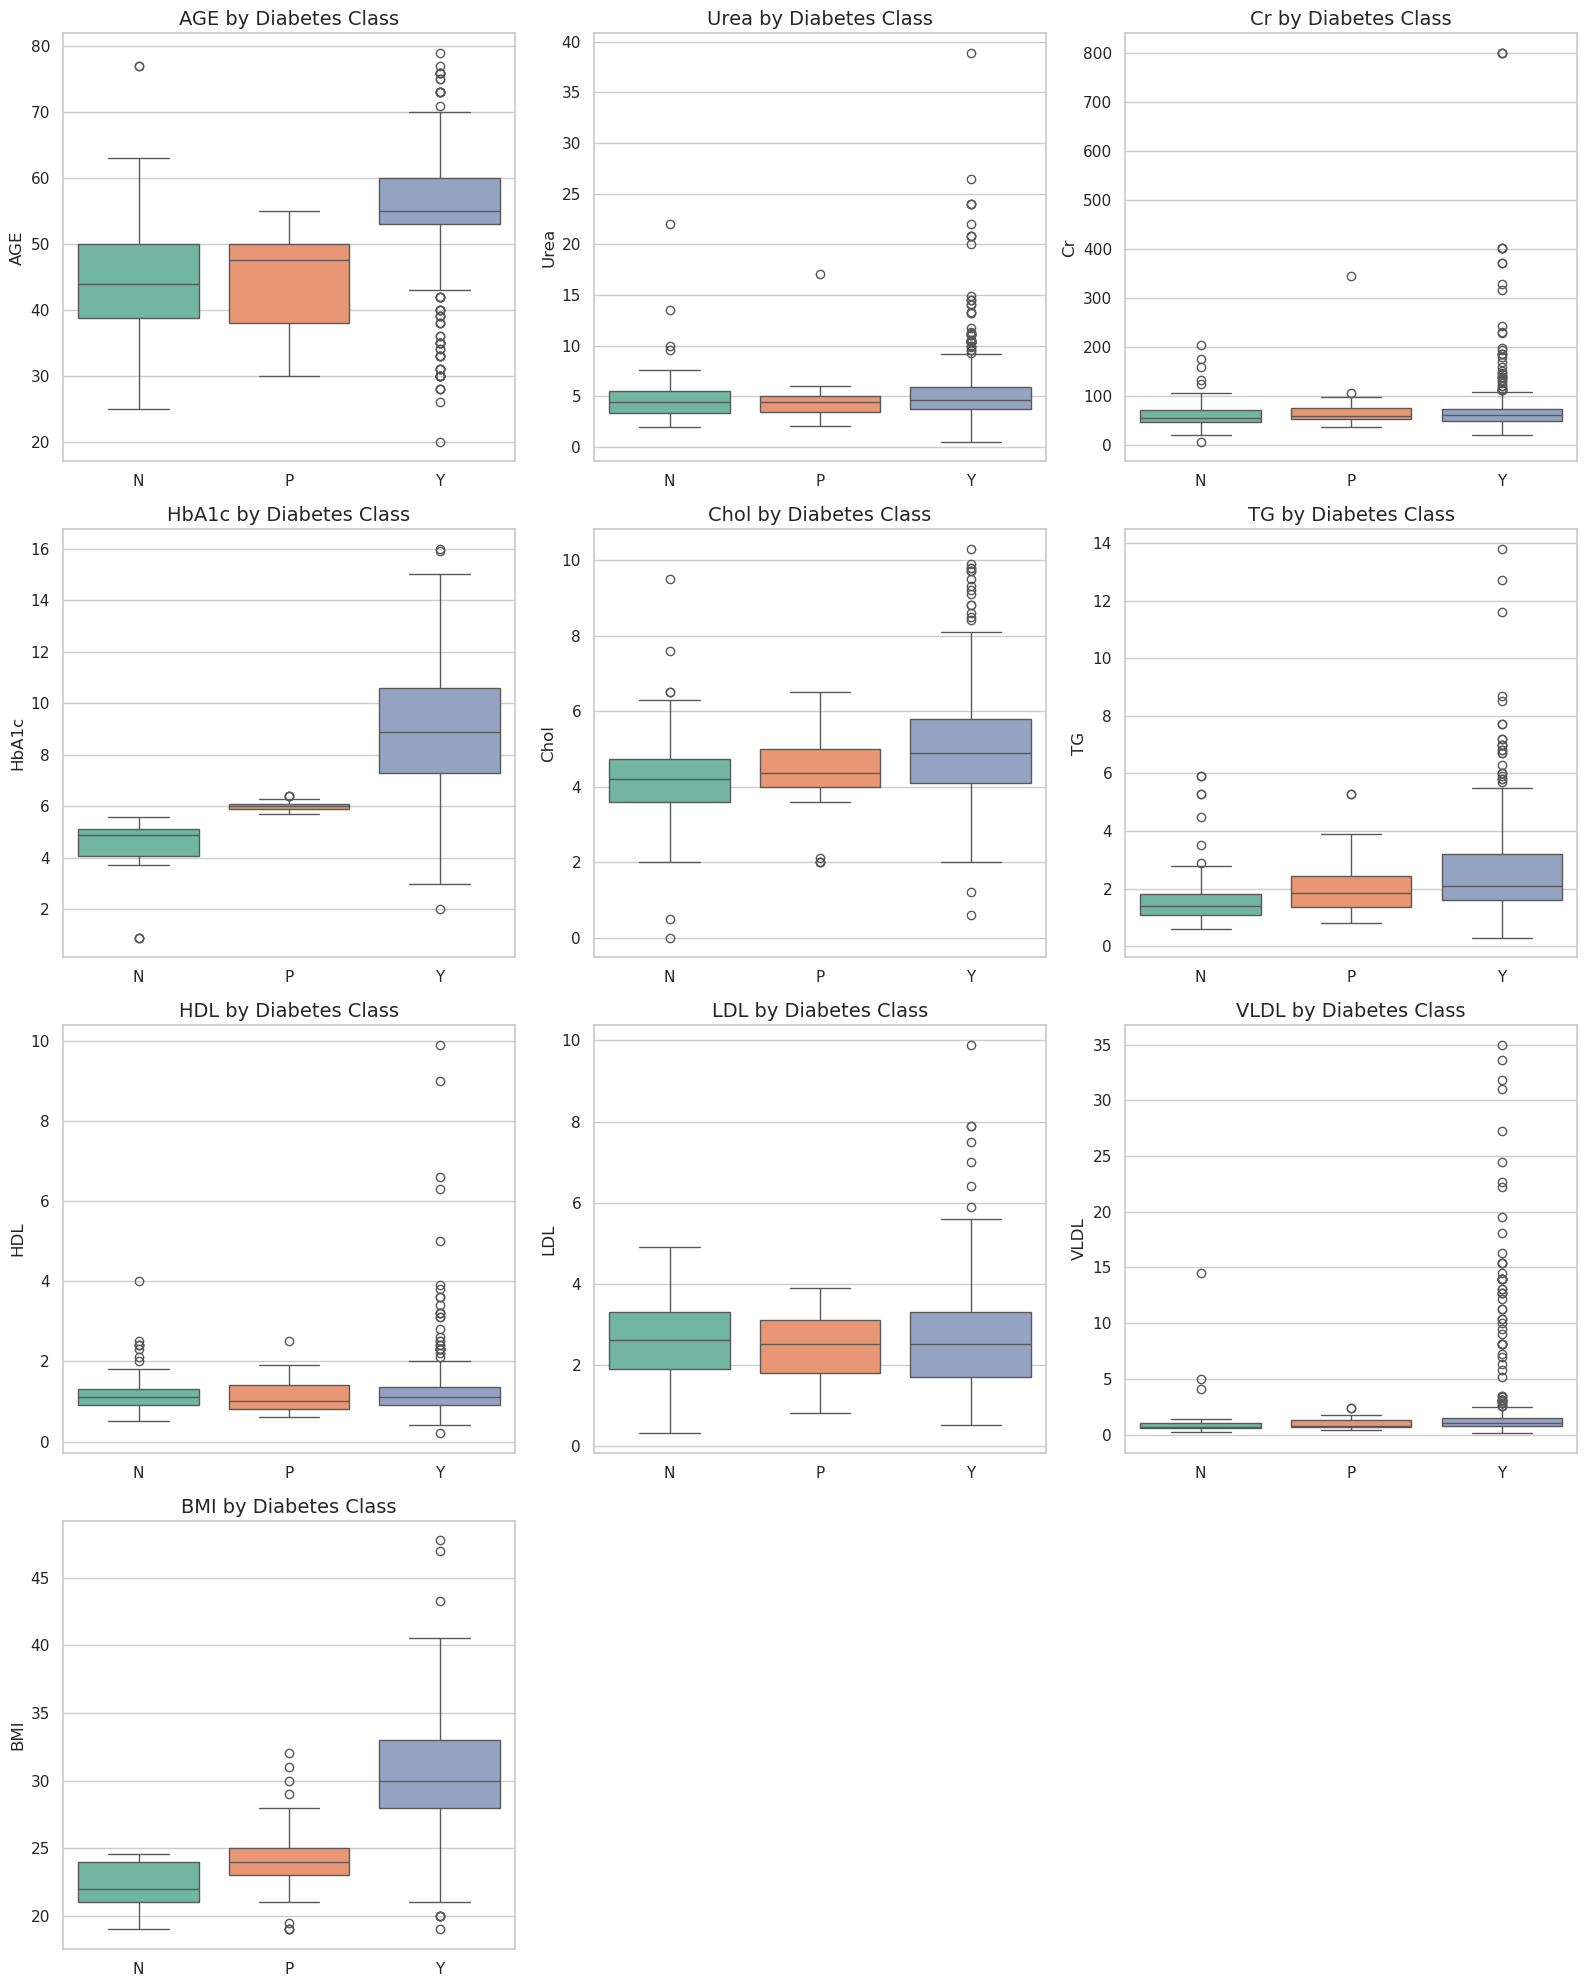

In [12]:
fig, axes = plt.subplots(4, 3, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='CLASS', y=col, order=['N', 'P', 'Y'], palette='Set2', ax=axes[i])
    axes[i].set_title(f'{col} by Diabetes Class')
    axes[i].set_xlabel('')

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### 3.2 Feature vs Class — Violin Plots

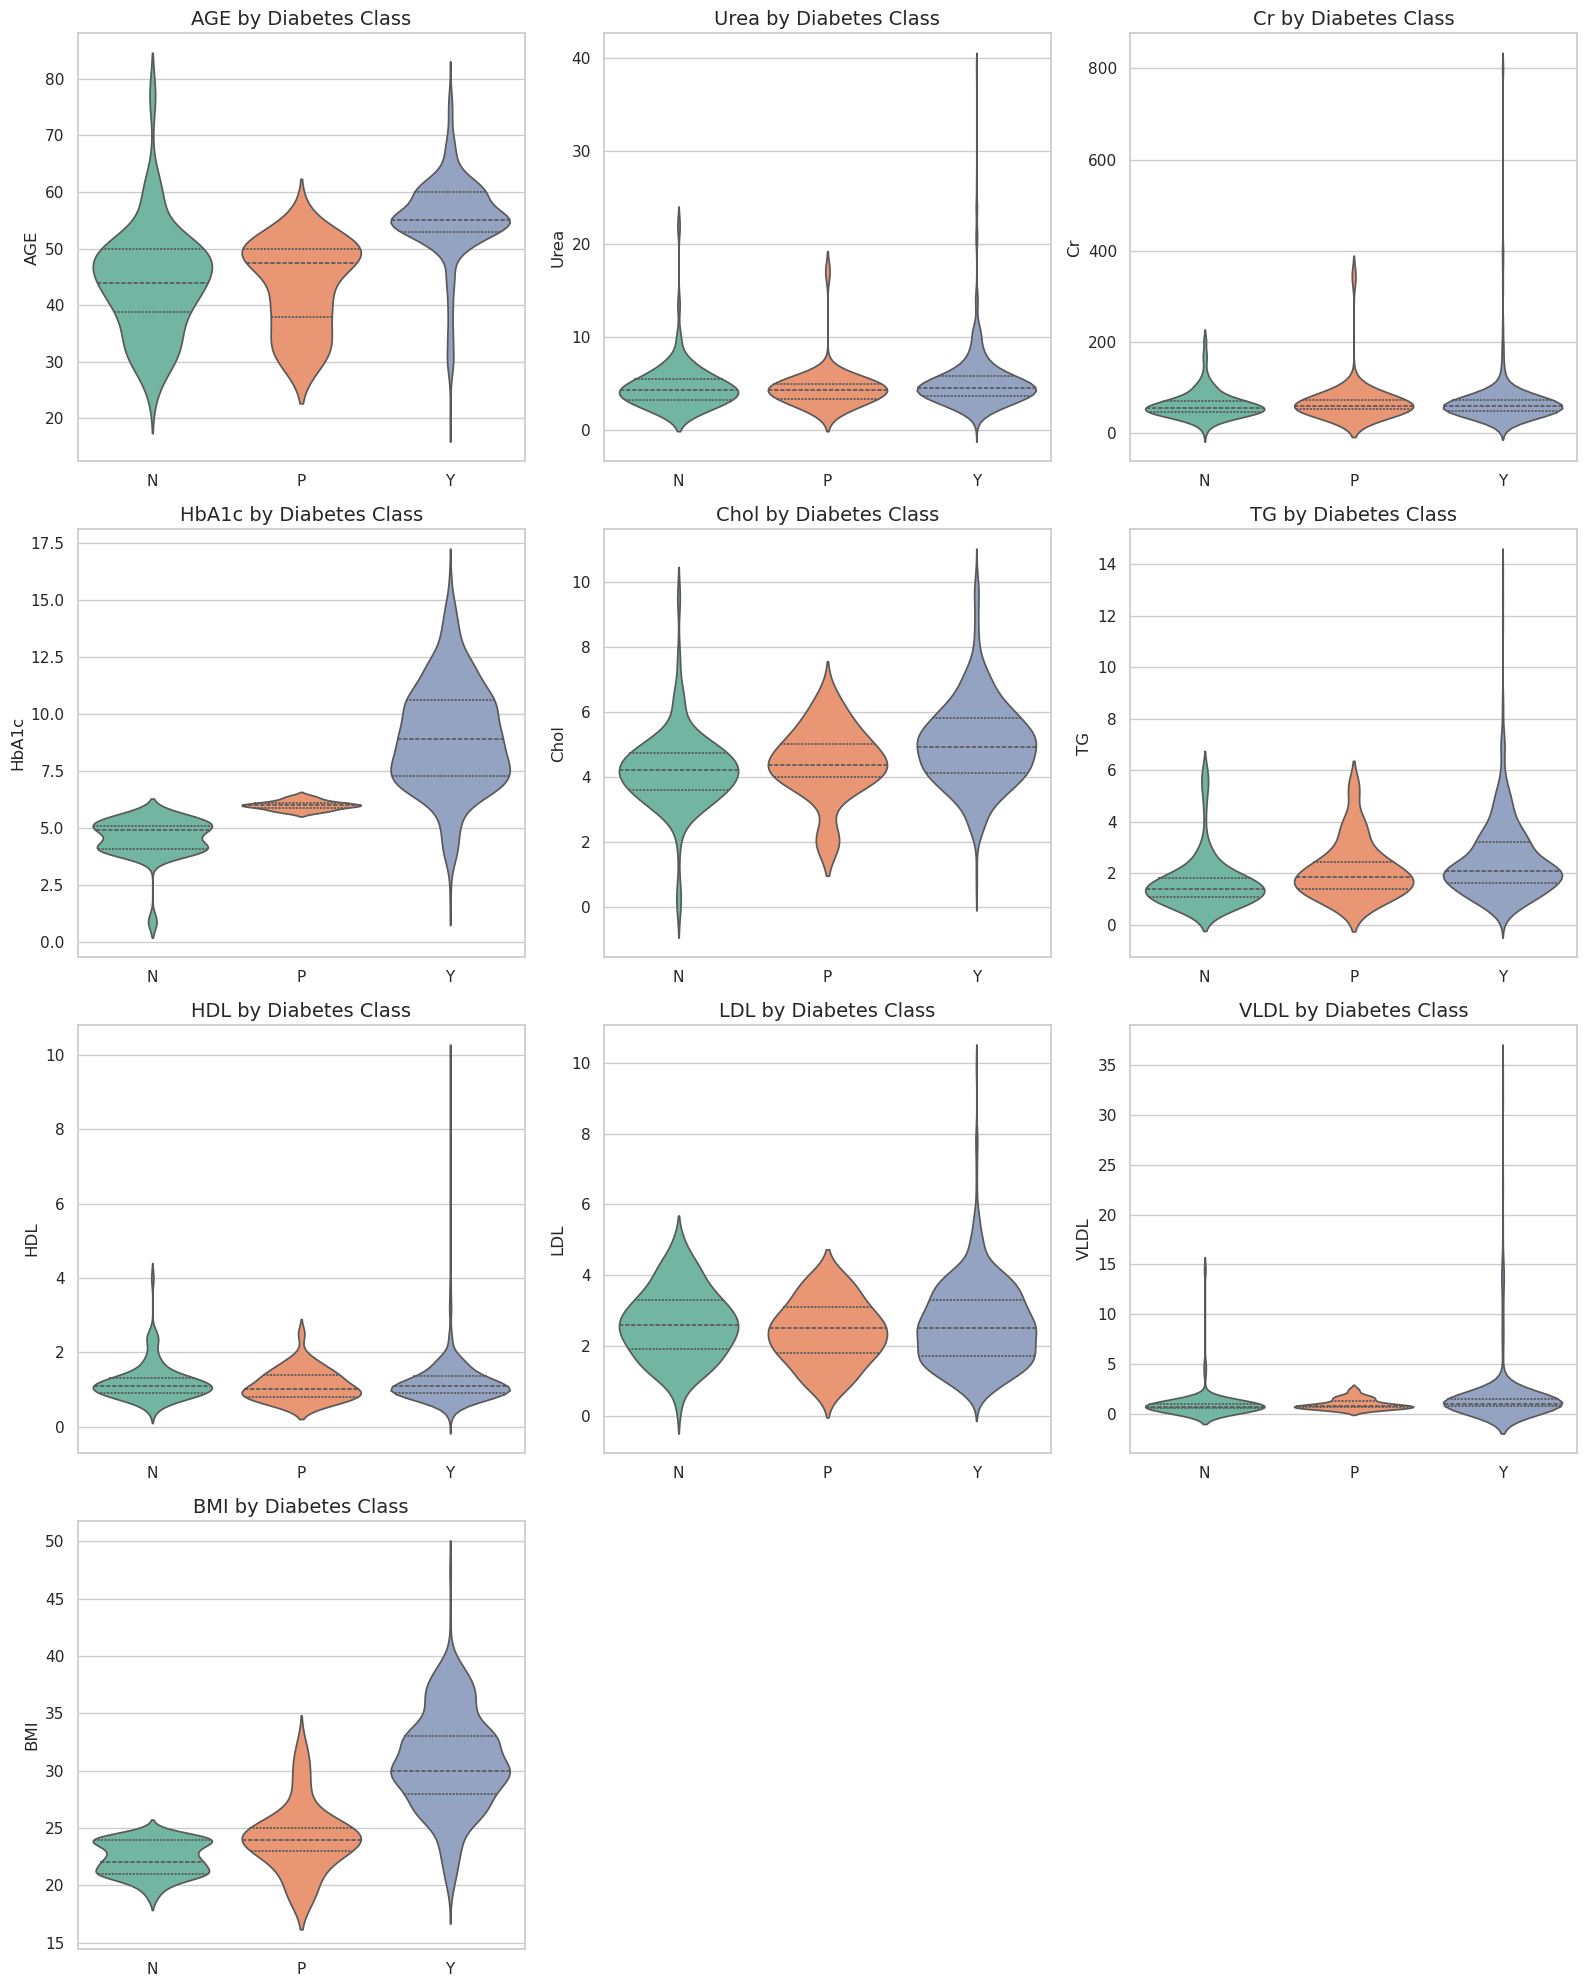

In [13]:
fig, axes = plt.subplots(4, 3, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.violinplot(data=df, x='CLASS', y=col, order=['N', 'P', 'Y'],
                   palette='Set2', ax=axes[i], inner='quartile')
    axes[i].set_title(f'{col} by Diabetes Class')
    axes[i].set_xlabel('')

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### 3.3 Class-wise Mean Comparison

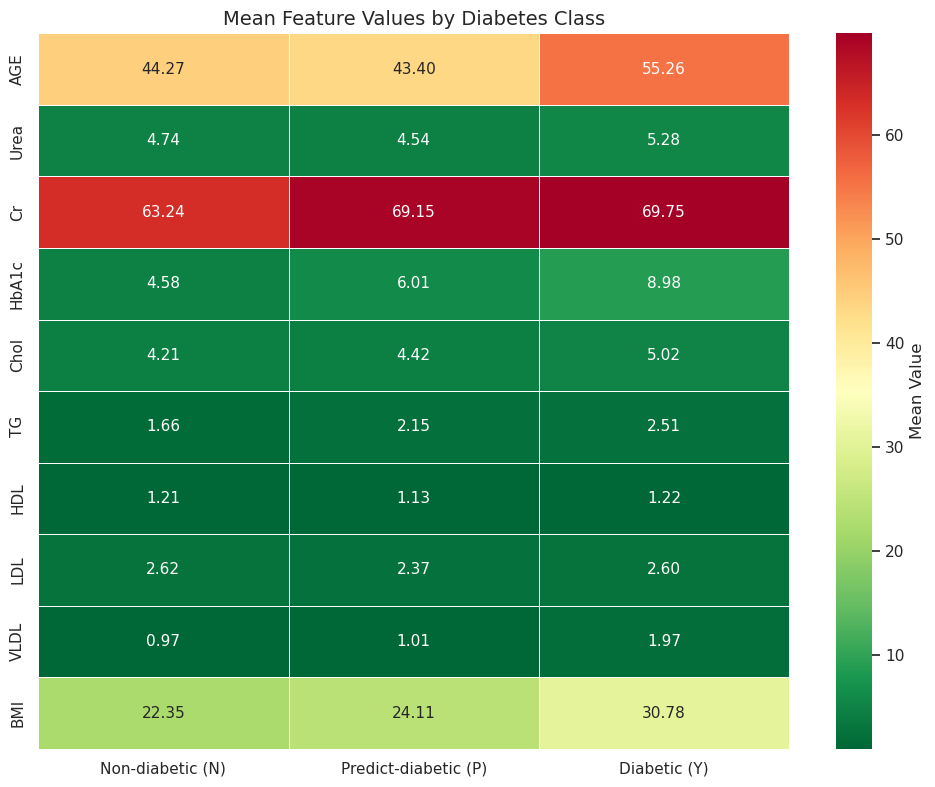

In [14]:
# Mean values per class
class_means = df.groupby('CLASS')[numeric_cols].mean().T
class_means.columns = ['Non-diabetic (N)', 'Predict-diabetic (P)', 'Diabetic (Y)']

# Heatmap of class-wise means
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(class_means, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Mean Value'})
ax.set_title('Mean Feature Values by Diabetes Class')
plt.tight_layout()
plt.show()

## 4. Exploratory Data Analysis — Multivariate

### 4.1 Correlation Heatmap

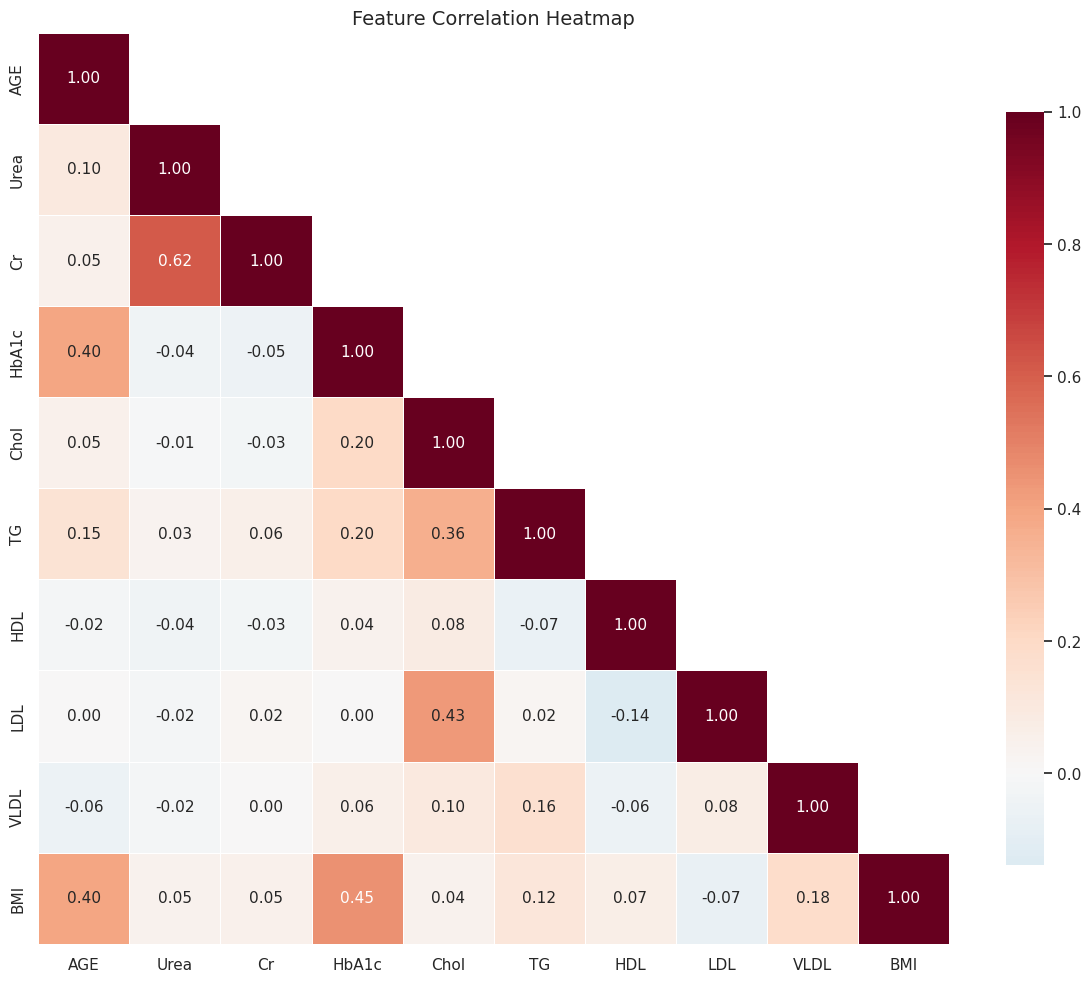

Strong feature correlations (|r| > 0.7):
  None found.


In [15]:
# Pearson correlation matrix
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax, square=True,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Find strong correlations
print('Strong feature correlations (|r| > 0.7):')
strong_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.7:
            strong_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], val))
if strong_corr:
    for a, b, v in strong_corr:
        print(f'  {a} — {b}: {v:.3f}')
else:
    print('  None found.')

### 4.2 Pairplot of Key Features

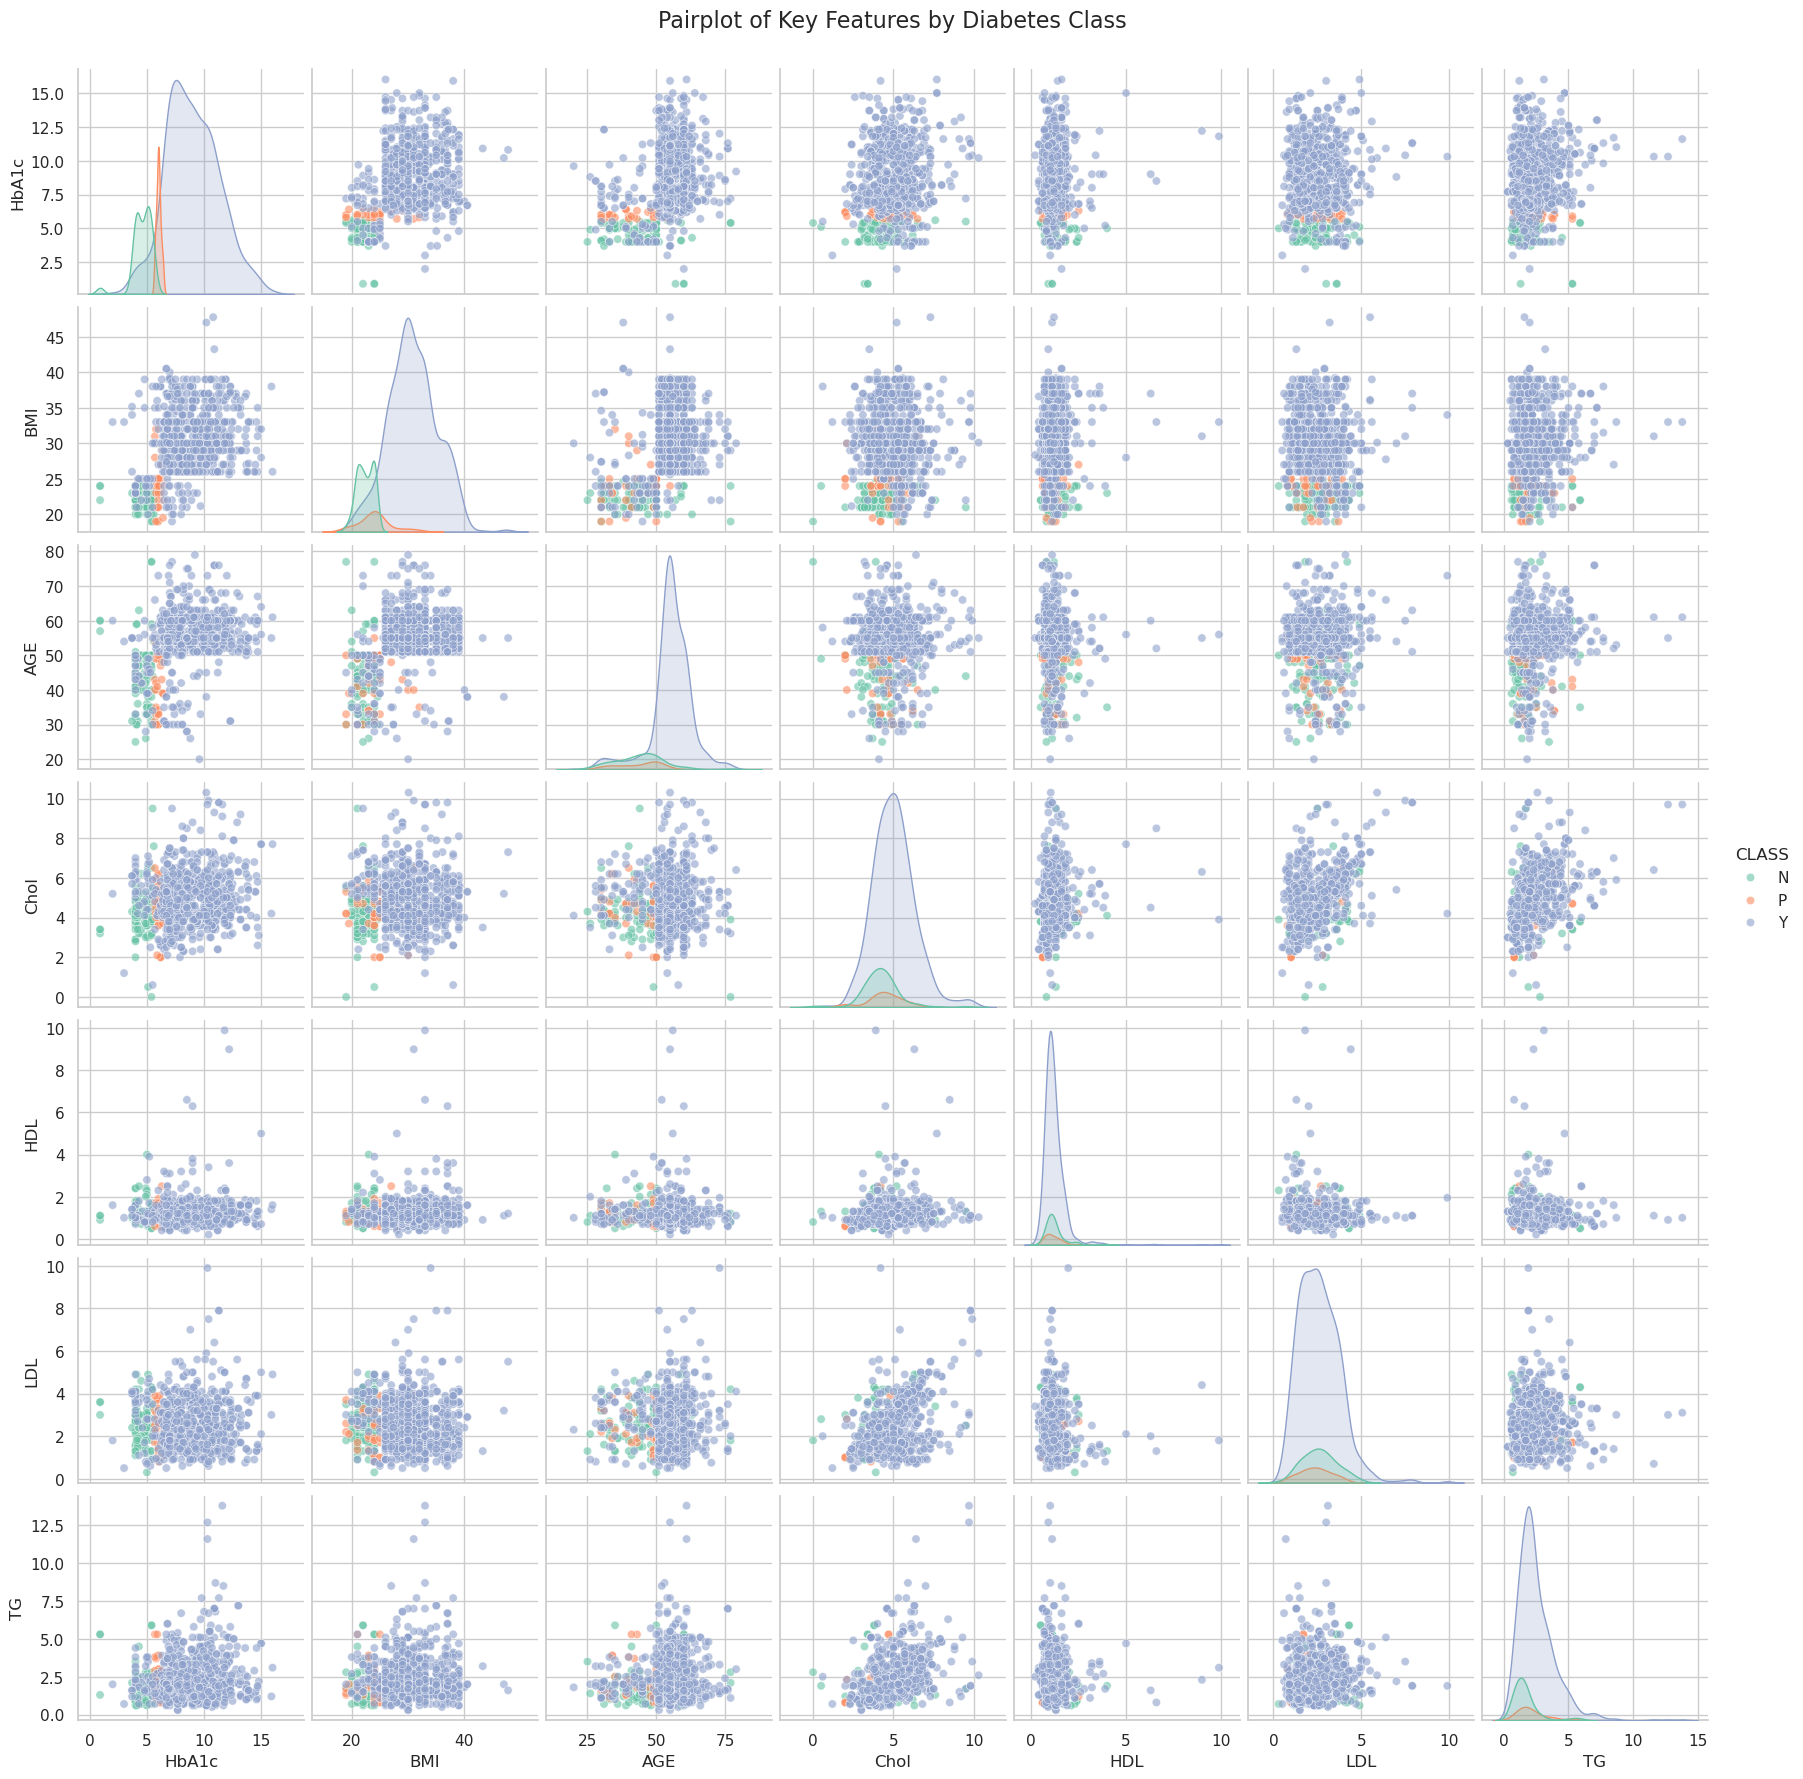

In [16]:
# Select top features based on visual differentiation
# Prioritize HbA1c, BMI, AGE, and lipid profile
key_features = ['HbA1c', 'BMI', 'AGE', 'Chol', 'HDL', 'LDL', 'TG']
g = sns.pairplot(df, vars=key_features, hue='CLASS', palette='Set2',
                 diag_kind='kde', plot_kws={'alpha': 0.6})
g.fig.suptitle('Pairplot of Key Features by Diabetes Class', y=1.02, fontsize=16)
plt.show()

### 4.3 ANOVA F-Test — Feature Discriminative Power

ANOVA F-Test Results (ranking features by discriminative power):


,Feature,F-Score,p-value
9,BMI,219.658297,2.952019e-77
3,HbA1c,204.193286,8.178762e-73
0,AGE,117.133637,1.598694e-45
4,Chol,19.285028,6.513836e-09
5,TG,15.753324,1.929185e-07
8,VLDL,4.435514,1.213184e-02
1,Urea,2.223932,1.088287e-01
7,LDL,0.824416,4.388504e-01
2,Cr,0.506729,6.026495e-01
6,HDL,0.328286,7.202509e-01


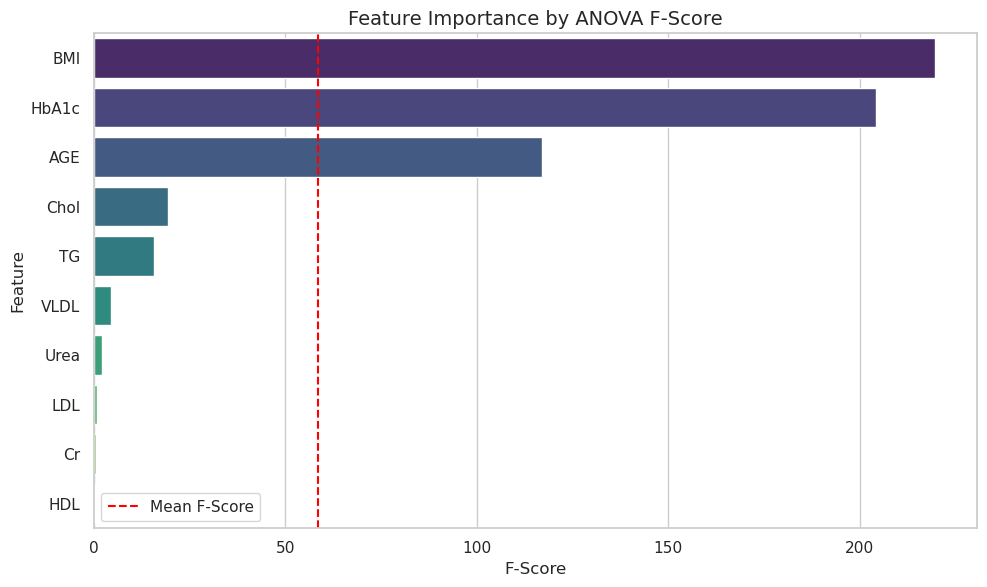

In [17]:
from sklearn.feature_selection import f_classif

# Encode CLASS for ANOVA
y_encoded = LabelEncoder().fit_transform(df['CLASS'])

# Compute ANOVA F-values
f_scores, p_values = f_classif(df[numeric_cols], y_encoded)

anova_df = pd.DataFrame({
    'Feature': numeric_cols,
    'F-Score': f_scores,
    'p-value': p_values
}).sort_values('F-Score', ascending=False)

print('ANOVA F-Test Results (ranking features by discriminative power):')
display(anova_df)

# Bar plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=anova_df, y='Feature', x='F-Score', palette='viridis', ax=ax)
ax.set_title('Feature Importance by ANOVA F-Score')
ax.axvline(anova_df['F-Score'].mean(), color='red', linestyle='--', label='Mean F-Score')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Outlier Detection and Analysis

### 5.1 IQR-Based Outlier Detection

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,AGE,51.00,59.0,8.00,39.000,71.000,82,9.87
1,Urea,3.63,5.7,2.07,0.525,8.805,57,6.86
8,VLDL,0.70,1.5,0.80,-0.500,2.700,57,6.86
2,Cr,48.00,73.0,25.00,10.500,110.500,46,5.54
6,HDL,0.90,1.3,0.40,0.300,1.900,42,5.05
5,TG,1.50,3.0,1.50,-0.750,5.250,36,4.33
4,Chol,4.00,5.6,1.60,1.600,8.000,23,2.77
7,LDL,1.70,3.3,1.60,-0.700,5.700,7,0.84
3,HbA1c,6.50,10.2,3.70,0.950,15.750,5,0.60
9,BMI,26.00,33.0,7.00,15.500,43.500,2,0.24


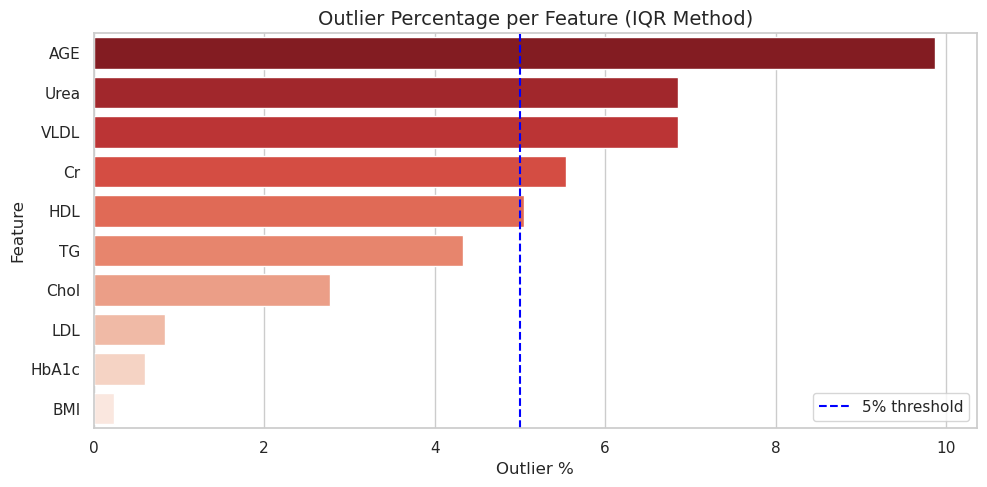

In [18]:
# IQR-based outlier detection for each numeric feature
outlier_summary = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary.append({
        'Feature': col,
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Lower Bound': lower, 'Upper Bound': upper,
        'Outlier Count': len(outliers),
        'Outlier %': round(len(outliers) / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('Outlier %', ascending=False)
display(outlier_df)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=outlier_df, y='Feature', x='Outlier %', palette='Reds_r', ax=ax)
ax.set_title('Outlier Percentage per Feature (IQR Method)')
ax.axvline(5, color='blue', linestyle='--', label='5% threshold')
ax.legend()
plt.tight_layout()
plt.show()

### 5.2 Domain-Specific Outlier Review

Clinical thresholds for flagging implausible values:

- **Cr (Creatinine):** Normal ~0.6–1.3 mg/dL; values >200 suggest end-stage renal disease or data error
- **HbA1c:** Normal <5.7%; values <3% are physiologically implausible
- **Chol:** Values near 0 are likely data errors

In [19]:
# Flag clinically implausible values
clinically_extreme = pd.DataFrame()
clinically_extreme['Cr > 200'] = df['Cr'] > 200
clinically_extreme['HbA1c < 3'] = df['HbA1c'] < 3
clinically_extreme['Chol < 0.5'] = df['Chol'] < 0.5
clinically_extreme['BMI > 60'] = df['BMI'] > 60
clinically_extreme['TG < 0.1'] = df['TG'] < 0.1

print('Clinically implausible values flagged:')
for col in clinically_extreme.columns:
    count = clinically_extreme[col].sum()
    if count > 0:
        print(f'  {col}: {count} rows')
        display(df[clinically_extreme[col]][['AGE', 'Cr', 'HbA1c', 'Chol', 'BMI', 'CLASS']].head())

Clinically implausible values flagged:
  Cr > 200: 15 rows


,AGE,Cr,HbA1c,Chol,BMI,CLASS
91,50.0,203.0,5.4,3.8,22.0,N
151,30.0,344.0,6.0,4.9,21.0,P
208,57.0,370.0,6.8,4.0,37.0,Y
212,57.0,370.0,6.8,6.1,37.0,Y
273,58.0,800.0,9.1,6.6,33.0,Y


  HbA1c < 3: 4 rows


,AGE,Cr,HbA1c,Chol,BMI,CLASS
80,57.0,97.0,0.9,3.2,22.0,N
92,60.0,70.0,0.9,3.4,24.0,N
98,60.0,70.0,0.9,3.4,24.0,N
554,60.0,74.0,2.0,5.2,33.0,Y


  Chol < 0.5: 1 rows


,AGE,Cr,HbA1c,Chol,BMI,CLASS
99,77.0,106.0,5.4,0.0,19.0,N


### 5.3 Outlier Treatment Strategy

- **Tree-based models** (Random Forest, XGBoost) are robust to outliers — no capping needed
- **Linear models** (Logistic Regression) benefit from capped/transformed features
- **For linear models:** Apply `RobustScaler` or a `QuantileTransformer` as alternative to `StandardScaler`
- **For clinically implausible values:** Cap at reasonable bounds using domain knowledge
- **Moderate outliers:** Retain — they carry important clinical signal (sick patients have extreme values)

## 6. Data Preprocessing

### 6.1 Train-Test Split (Stratified)

In [20]:
# Separate features and target
X = df.drop(columns=['CLASS'])
y = df['CLASS']

# Encode target: N=0, P=1, Y=2
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(f'Class mapping: {dict(zip(label_encoder.classes_, range(3)))}')
print(f'Target distribution: {dict(zip(label_encoder.classes_, np.bincount(y_encoded)))}')

# Stratified split preserves class proportions in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=RANDOM_STATE
)

print(f'\nTraining set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')
print(f'\nTrain class distribution:')
for cls, count in zip(label_encoder.classes_, np.bincount(y_train)):
    print(f'  {cls}: {count} ({count/len(y_train)*100:.1f}%)')
print(f'\nTest class distribution:')
for cls, count in zip(label_encoder.classes_, np.bincount(y_test)):
    print(f'  {cls}: {count} ({count/len(y_test)*100:.1f}%)')

Class mapping: {'N': 0, 'P': 1, 'Y': 2}
Target distribution: {'N': 96, 'P': 40, 'Y': 695}

Training set: 664 samples
Test set: 167 samples

Train class distribution:
  N: 77 (11.6%)
  P: 32 (4.8%)
  Y: 555 (83.6%)

Test class distribution:
  N: 19 (11.4%)
  P: 8 (4.8%)
  Y: 140 (83.8%)


### 6.2 Feature Encoding and Scaling

- **Gender:** Binary → Label Encode (F=0, M=1)
- **Numeric features:** StandardScaler (z-score normalization)
- Combined with `ColumnTransformer`

In [21]:
# Identify column types
numeric_features = ['AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI']
categorical_features = ['Gender']

# Build preprocessor
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first'), categorical_features)
])

print(f'Numeric features ({len(numeric_features)}): {numeric_features}')
print(f'Categorical features ({len(categorical_features)}): {categorical_features}')
print('Preprocessor: StandardScaler + OneHotEncoder(drop=first)')

Numeric features (10): ['AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI']
Categorical features (1): ['Gender']
Preprocessor: StandardScaler + OneHotEncoder(drop=first)


### 6.3 Handling Class Imbalance with SMOTE

The dataset is severely imbalanced (Y=844, N=103, P=53). SMOTE generates synthetic samples for minority classes.

**CRITICAL:** SMOTE must be applied ONLY to training data and WITHIN cross-validation folds to prevent data leakage.

Class distribution BEFORE SMOTE:
  N: 77
  P: 32
  Y: 555
Class distribution AFTER SMOTE:
  N: 555
  P: 555
  Y: 555


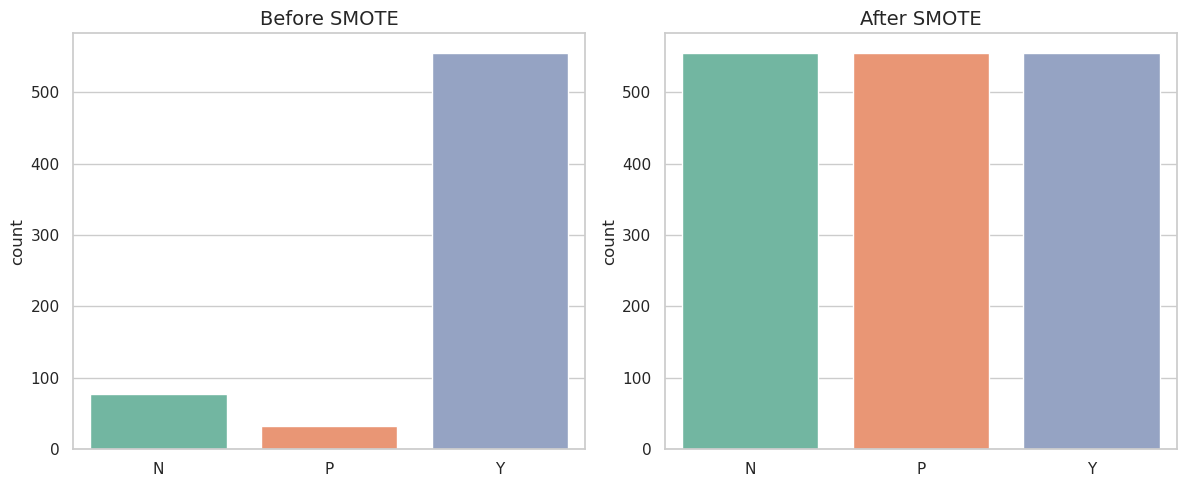

In [22]:
# Apply SMOTE to training data for visualization
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(
    preprocessor.fit_transform(X_train), y_train
)

print('Class distribution BEFORE SMOTE:')
for cls, count in zip(label_encoder.classes_, np.bincount(y_train)):
    print(f'  {cls}: {count}')

print('Class distribution AFTER SMOTE:')
for cls, count in zip(label_encoder.classes_, np.bincount(y_train_smote)):
    print(f'  {cls}: {count}')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x=[label_encoder.inverse_transform([i])[0] for i in y_train],
              order=['N', 'P', 'Y'], palette='Set2', ax=axes[0])
axes[0].set_title('Before SMOTE')
sns.countplot(x=[label_encoder.inverse_transform([i])[0] for i in y_train_smote],
              order=['N', 'P', 'Y'], palette='Set2', ax=axes[1])
axes[1].set_title('After SMOTE')
plt.tight_layout()
plt.show()

### 6.4 Pipeline-Ready Preprocessor

For proper cross-validation, we will use `imblearn.pipeline.Pipeline` (not sklearn's) to chain:
1. **ColumnTransformer** (scale numeric, encode categorical)
2. **SMOTE** (oversample minority classes)
3. **Classifier** (any sklearn-compatible model)

This ensures SMOTE is applied fold-by-fold during cross-validation, preventing data leakage.